# Low-Resource Customer Feedback Sentiment Analysis

In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.config import *
from src.dataset import *
from src.model import *
from src.utils import *

In [2]:
print("Device:", DEVICE)
print("Model:", MODEL_NAME)

Device: cpu
Model: distilbert-base-uncased


In [3]:
train_df, valid_df, test_df, unlabelled_df = load_data()

print(train_df.head())

  sentiment                                               text
0  positive  Perfect fit. 2014 durango limited. Super easy ...
1  negative  Better fans out there for the price. Switch wa...
2  positive  This is easy enough to install.  There is a re...
3  positive  Great product for dual wheels. Use them on the...
4  positive  This thing is amazing. I bought one for my hus...


In [4]:
print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)
print(unlabelled_df.shape)

(1000, 2)
(100, 2)
(250, 2)
(1000, 1)


In [5]:
train_df["sentiment"].value_counts()

sentiment
positive    782
negative    218
Name: count, dtype: int64

In [6]:
train_dataset, valid_dataset, test_dataset, unlabelled_dataset, tokenizer = get_datasets()

print(train_dataset[0])

{'input_ids': tensor([  101,  3819,  4906,  1012,  2297, 22959,  3995,  3132,  1012,  3565,
         3733,  2000, 16500,  1012,  2625,  2084,  2322,  8117,  1012,  4530,
         1996,  8622,  1010, 25672,  1018, 19947,  1998,  2404,  2009,  2067,
         2362,  1012,  3082,  1011,  4611,  1012,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'labels': tensor(1)}


In [7]:
model = load_model()

print_model_summary(model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model Summary
--------------------------------------------------
Model Name       : distilbert-base-uncased
Device           : cpu
Number of Labels : 2
Max Length       : 64
Trainable Params : 66,955,010


In [8]:
%run src/train.py

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/3


100%|██████████| 125/125 [05:28<00:00,  2.63s/it]


Training Loss : 0.4959
Validation Accuracy : 0.8300


...

Training Loss : 0.2550
Validation Accuracy : 0.8900


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: C:\HP LAPTOP\Projects\Low-Resource-Customer-Feedback-Sentiment-Analysis\outputs\best_model
Best model saved.

Epoch 3/3


100%|██████████| 125/125 [05:27<00:00,  2.62s/it]


Training Loss : 0.1129
Validation Accuracy : 0.8800

Training completed.
Metrics saved to: C:\HP LAPTOP\Projects\Low-Resource-Customer-Feedback-Sentiment-Analysis\outputs\metrics.txt

Evaluation Results
------------------------------
Accuracy    : 0.8900
Precision   : 0.9231
Recall      : 0.9351
F1          : 0.9290


In [9]:
%run src/evaluate.py

Loading model...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:17<00:00,  1.06s/it]



Evaluation Results
------------------------------
Accuracy    : 0.8640
Precision   : 0.9038
Recall      : 0.9307
F1          : 0.9171
Metrics saved to: C:\HP LAPTOP\Projects\Low-Resource-Customer-Feedback-Sentiment-Analysis\outputs\metrics.txt

Evaluation completed.
Metrics saved to: C:\HP LAPTOP\Projects\Low-Resource-Customer-Feedback-Sentiment-Analysis\outputs\metrics.txt
Predictions saved to: C:\HP LAPTOP\Projects\Low-Resource-Customer-Feedback-Sentiment-Analysis\outputs\predictions.csv
Confusion matrix saved to: C:\HP LAPTOP\Projects\Low-Resource-Customer-Feedback-Sentiment-Analysis\outputs\confusion_matrix.png


In [10]:
with open("outputs/metrics.txt") as file:
    print(file.read())

accuracy: 0.8640
precision: 0.9038
recall: 0.9307
f1: 0.9171



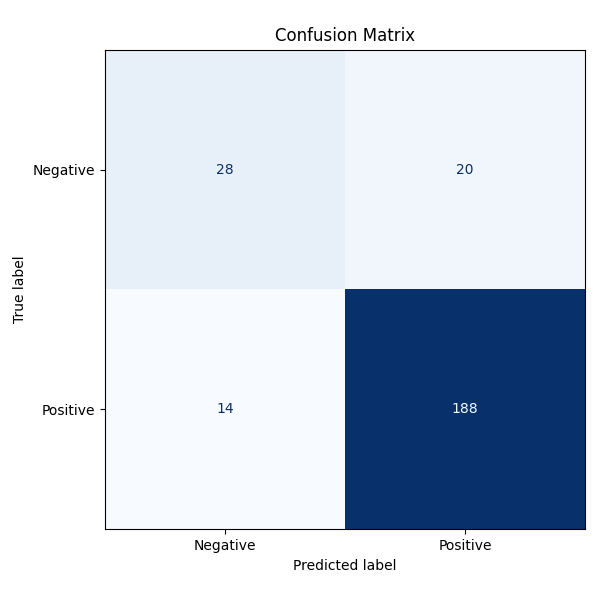

In [11]:
from PIL import Image

Image.open("outputs/confusion_matrix.png")

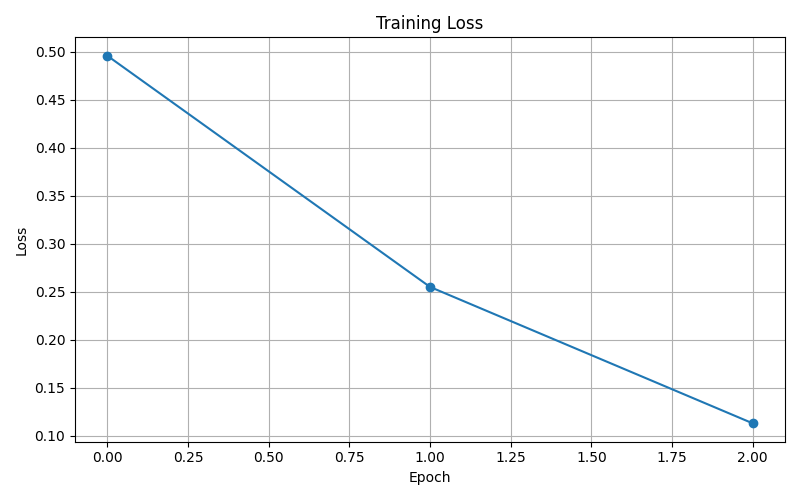

In [12]:
Image.open("outputs/training_loss.png")

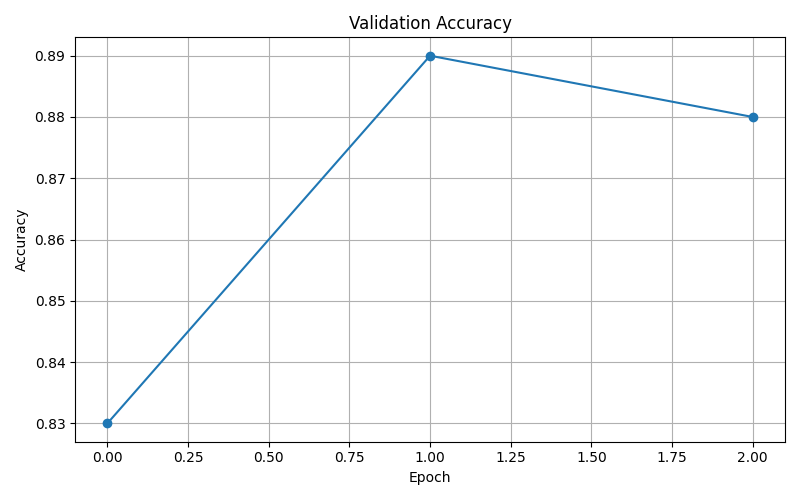

In [13]:
Image.open("outputs/validation_accuracy.png")

In [14]:
text = "The product quality is excellent."

encoding = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
)

encoding = {k: v.to(DEVICE) for k, v in encoding.items()}

model.eval()

with torch.no_grad():
    outputs = model(**encoding)

prediction = torch.argmax(outputs.logits, dim=1).item()

print(ID2LABEL[prediction])

positive


In [15]:
text = "The delivery was terrible and customer support was disappointing."

encoding = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
)

encoding = {k: v.to(DEVICE) for k, v in encoding.items()}

with torch.no_grad():
    outputs = model(**encoding)

prediction = torch.argmax(outputs.logits, dim=1).item()

print(ID2LABEL[prediction])

negative


In [16]:
print("Notebook execution completed successfully.")

Notebook execution completed successfully.


In [2]:
from pathlib import Path

outputs = Path("outputs")

for file in sorted(outputs.rglob("*metrics.txt")):
    print("=" * 80)
    print(file)
    print("=" * 80)

    with open(file, "r") as f:
        print(f.read())

outputs\bert-base-uncased\metrics.txt
accuracy: 0.9000
precision: 0.9740
recall: 0.9036
f1: 0.9375

outputs\bert-base-uncased\test_metrics.txt
accuracy: 0.8840
precision: 0.9703
recall: 0.8950
f1: 0.9311

outputs\distilbert-cpu\metrics.txt
accuracy: 0.8640
precision: 0.9038
recall: 0.9307
f1: 0.9171

outputs\google_electra-base-discriminator\metrics.txt
accuracy: 0.9300
precision: 0.9610
recall: 0.9487
f1: 0.9548

outputs\google_electra-base-discriminator\test_metrics.txt
accuracy: 0.8760
precision: 0.9455
recall: 0.9052
f1: 0.9249

outputs\microsoft_deberta-v3-base\metrics.txt
accuracy: 0.9100
precision: 0.9351
recall: 0.9474
f1: 0.9412

outputs\microsoft_deberta-v3-base\test_metrics.txt
accuracy: 0.8760
precision: 0.9257
recall: 0.9212
f1: 0.9235

outputs\microsoft_deberta-v3-large\metrics.txt
accuracy: 0.9400
precision: 0.9610
recall: 0.9610
f1: 0.9610

outputs\microsoft_deberta-v3-large\test_metrics.txt
accuracy: 0.9240
precision: 0.9703
recall: 0.9378
f1: 0.9538

outputs\microsoft

In [3]:
import pandas as pd
from pathlib import Path

rows = []

for folder in sorted(Path("outputs").iterdir()):
    if not folder.is_dir():
        continue

    metrics = {}
    test_metrics = {}

    metric_file = folder / "metrics.txt"
    test_file = folder / "test_metrics.txt"

    if metric_file.exists():
        with open(metric_file) as f:
            for line in f:
                k, v = line.strip().split(":")
                metrics[k.strip()] = float(v)

    if test_file.exists():
        with open(test_file) as f:
            for line in f:
                k, v = line.strip().split(":")
                test_metrics[k.strip()] = float(v)

    rows.append({
        "Model": folder.name,
        "Validation Accuracy": metrics.get("accuracy"),
        "Validation F1": metrics.get("f1"),
        "Test Accuracy": test_metrics.get("accuracy"),
        "Test F1": test_metrics.get("f1"),
    })

df = pd.DataFrame(rows)
df.sort_values("Test Accuracy", ascending=False)

,Model,Validation Accuracy,Validation F1,Test Accuracy,Test F1
4,microsoft_deberta-v3-large,0.940,0.9610,0.924,0.9538
5,microsoft_deberta-v3-small,0.930,0.9542,0.908,0.9438
7,roberta-base,0.910,0.9427,0.888,0.9327
0,bert-base-uncased,0.900,0.9375,0.884,0.9311
2,google_electra-base-discriminator,0.930,0.9548,0.876,0.9249
3,microsoft_deberta-v3-base,0.910,0.9412,0.876,0.9235
6,microsoft_MiniLM-L12-H384-uncased,0.930,0.9548,0.852,0.9082
1,distilbert-cpu,0.864,0.9171,NaN,NaN



bert-base-uncased


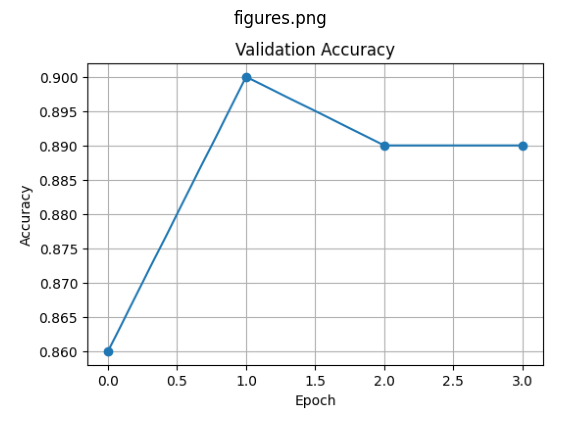


distilbert-cpu


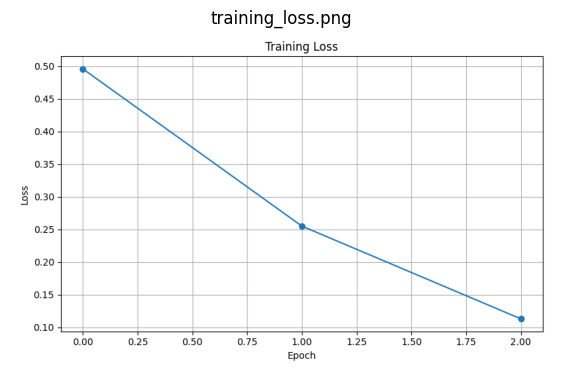

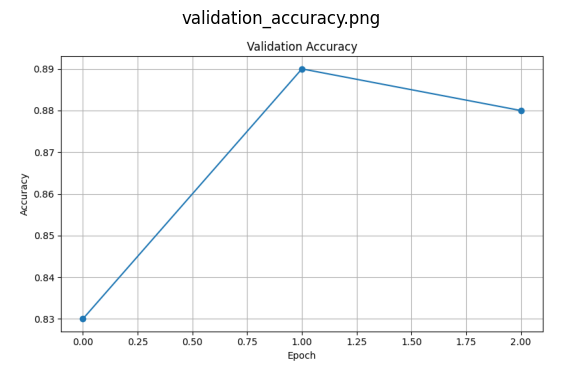

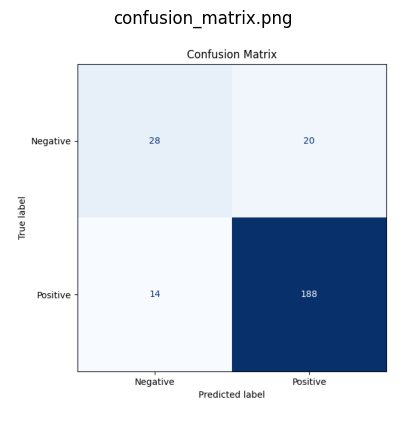


google_electra-base-discriminator


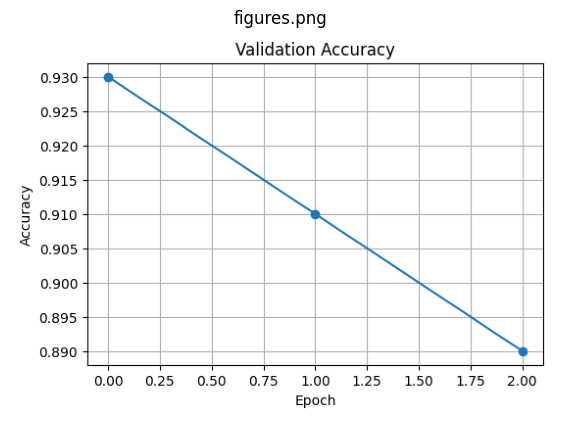


microsoft_deberta-v3-base


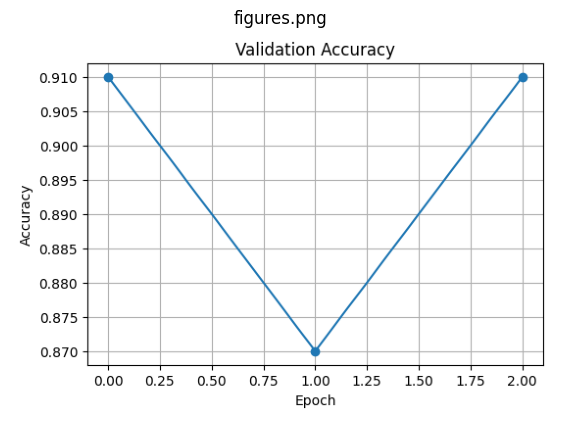

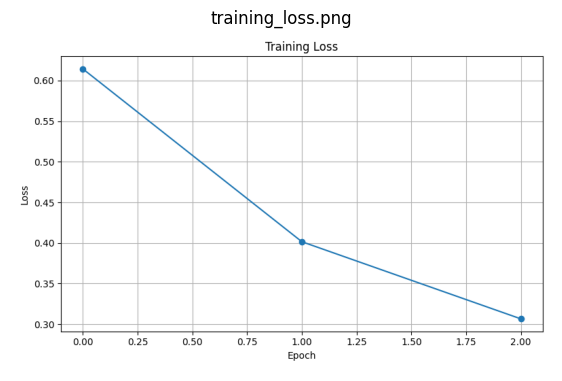

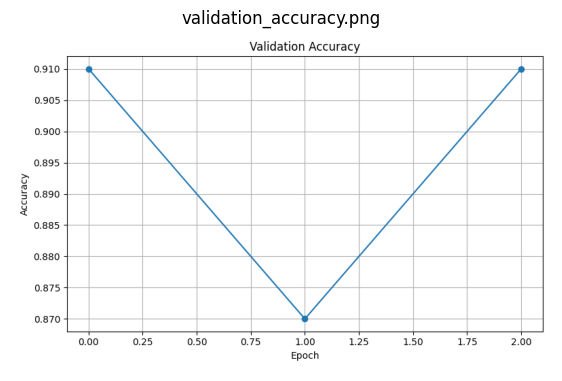

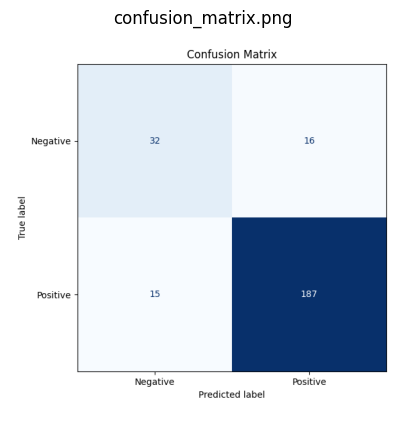


microsoft_deberta-v3-large


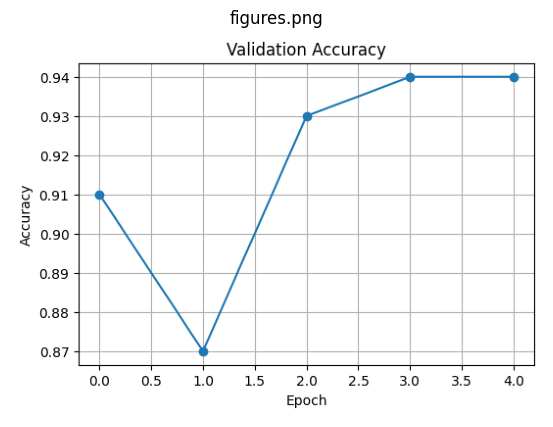


microsoft_deberta-v3-small


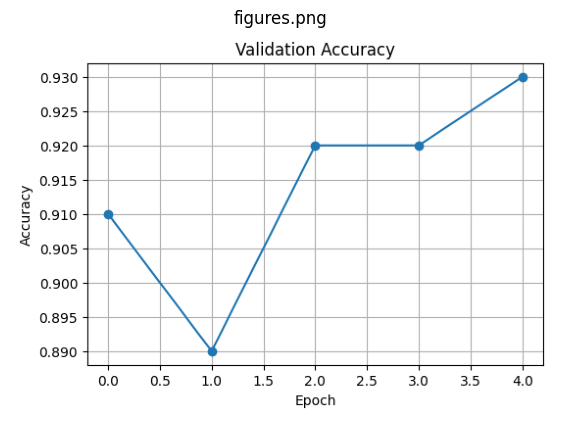


microsoft_MiniLM-L12-H384-uncased


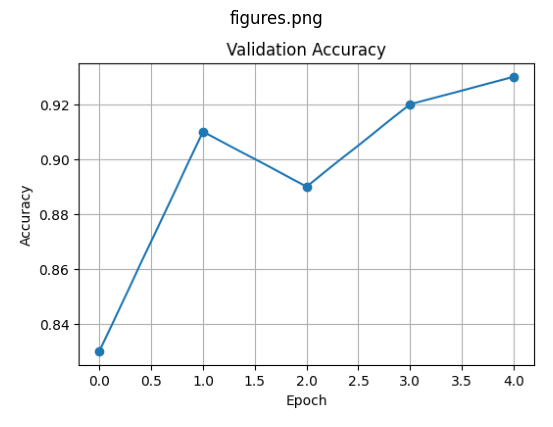


roberta-base


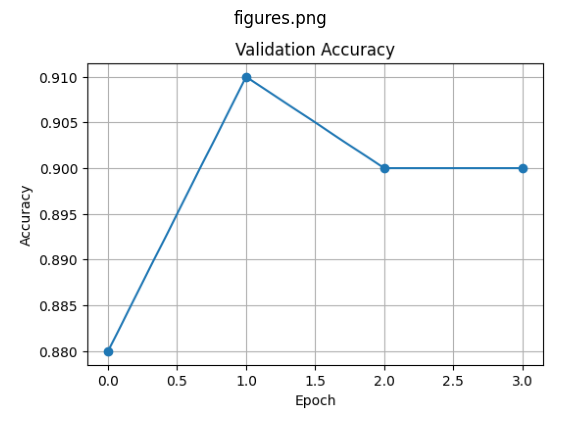

In [4]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

image_names = [
    "figures.png",
    "training_loss.png",
    "validation_accuracy.png",
    "confusion_matrix.png"
]

for model_dir in sorted(Path("outputs").iterdir()):
    if not model_dir.is_dir():
        continue

    print("\n", "=" * 80)
    print(model_dir.name)
    print("=" * 80)

    for image_name in image_names:
        image_path = model_dir / image_name

        if image_path.exists():
            img = Image.open(image_path)

            plt.figure(figsize=(7,5))
            plt.imshow(img)
            plt.axis("off")
            plt.title(image_name)
            plt.show()

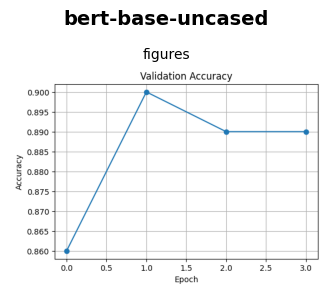

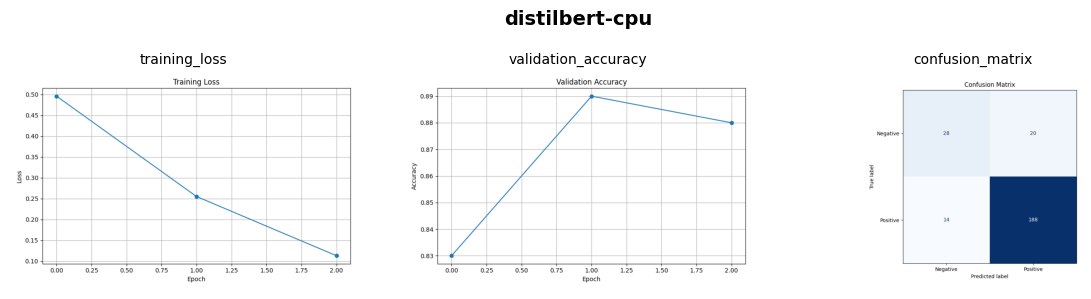

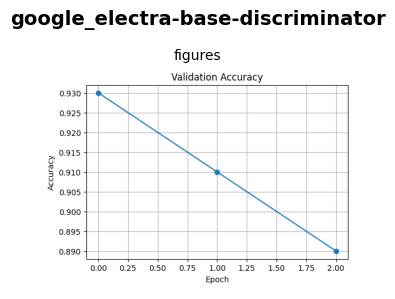

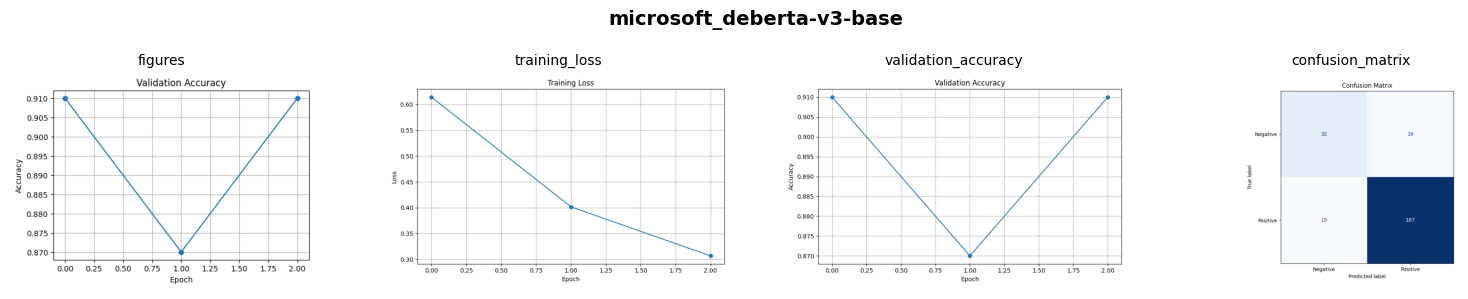

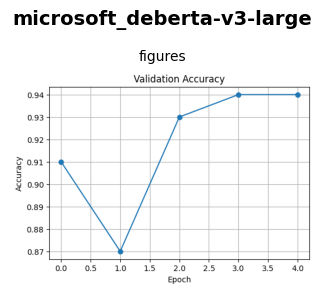

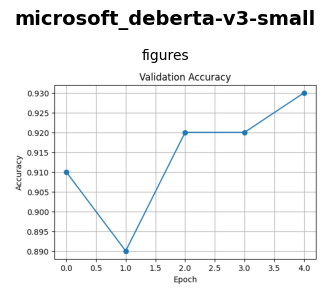

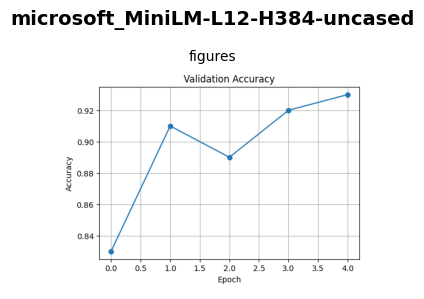

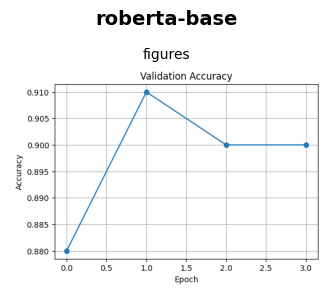

In [5]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

image_names = [
    "figures.png",
    "training_loss.png",
    "validation_accuracy.png",
    "confusion_matrix.png"
]

for model_dir in sorted(Path("outputs").iterdir()):
    if not model_dir.is_dir():
        continue

    existing_images = [
        model_dir / img
        for img in image_names
        if (model_dir / img).exists()
    ]

    if not existing_images:
        continue

    cols = len(existing_images)

    fig, axes = plt.subplots(1, cols, figsize=(4 * cols, 3))

    if cols == 1:
        axes = [axes]

    fig.suptitle(model_dir.name, fontsize=14, fontweight="bold")

    for ax, img_path in zip(axes, existing_images):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(img_path.stem, fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [6]:
summary = pd.DataFrame({
    "Rank":[1,2,3,4,5,6,7,8],
    "Model":[
        "DeBERTa-v3 Large",
        "DeBERTa-v3 Small",
        "RoBERTa Base",
        "BERT Base",
        "ELECTRA Base",
        "DeBERTa-v3 Base",
        "DistilBERT",
        "MiniLM"
    ],
    "Test Accuracy":[
        0.924,
        0.908,
        0.888,
        0.884,
        0.876,
        0.876,
        0.864,
        0.852
    ],
    "Test F1":[
        0.9538,
        0.9438,
        0.9327,
        0.9311,
        0.9249,
        0.9235,
        0.9171,
        0.9082
    ]
})

summary

,Rank,Model,Test Accuracy,Test F1
0,1,DeBERTa-v3 Large,0.924,0.9538
1,2,DeBERTa-v3 Small,0.908,0.9438
2,3,RoBERTa Base,0.888,0.9327
3,4,BERT Base,0.884,0.9311
4,5,ELECTRA Base,0.876,0.9249
5,6,DeBERTa-v3 Base,0.876,0.9235
6,7,DistilBERT,0.864,0.9171
7,8,MiniLM,0.852,0.9082


# Final Observations

- Eight transformer models were evaluated under a low-resource sentiment analysis setting.
- DeBERTa-v3 Large achieved the highest test accuracy (92.4%) and F1-score (95.38%).
- DeBERTa-v3 Small provided the best balance between computational cost and predictive performance.
- DistilBERT enabled rapid experimentation with lower computational requirements.
- The experiments demonstrate the effectiveness of transfer learning for low-resource NLP tasks.
- Future work will incorporate pseudo-labeling and semi-supervised learning using the unlabelled dataset.